# Train-test split and scaling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_clean = pd.read_csv("cleaned_data.csv")

In [3]:
from sklearn.model_selection import train_test_split

# 1️⃣ Separate features and target
X = df_clean.drop('status', axis=1)
y = df_clean['status']

# 2️⃣ Train-test split (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # preserve class distribution
)

# 3️⃣ Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))



X_train shape: (156, 19)
X_test shape: (39, 19)
y_train distribution:
 status
1    0.75641
0    0.24359
Name: proportion, dtype: float64
y_test distribution:
 status
1    0.74359
0    0.25641
Name: proportion, dtype: float64


# Class balancce using SMOTE

In [4]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after SMOTE:")
print(y_train_res.value_counts())

Class distribution after SMOTE:
status
0    118
1    118
Name: count, dtype: int64


# Standardize features using RobustScaler

In [5]:
from sklearn.preprocessing import RobustScaler

# Initialize RobustScaler
scaler = RobustScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train_res)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Optional: Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Logisitc Regression Model

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train_scaled, y_train_res)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Predict on test set
y_pred_rf = rf.predict(X_test_scaled)



In [12]:
# Evaluate
print("--- Random Forest Classifier ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

--- Random Forest Classifier ---
Accuracy: 0.8462

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.93      0.86      0.89        29

    accuracy                           0.85        39
   macro avg       0.80      0.83      0.81        39
weighted avg       0.86      0.85      0.85        39

Confusion Matrix:
 [[ 8  2]
 [ 4 25]]


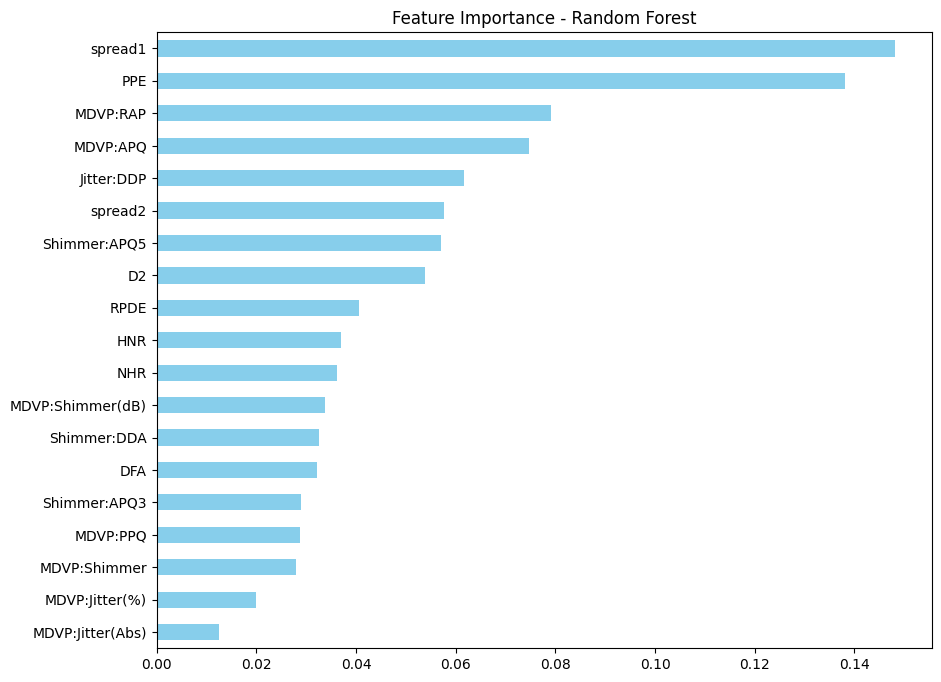

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.sort_values().plot(kind='barh', figsize=(10,8), color='skyblue')
plt.title("Feature Importance - Random Forest")
plt.show()